In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def load_image_gray(path):
    """이미지를 그레이스케일로 불러오기"""
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)

def compute_gradients(img):
    #구현 필요
    #입력된 이미지에 대해 sobel 필터를 이용해 x,y 기울기 맵을 계산해 반환
    #3×3 Sobel 커널 생성
    sobelx = np.array([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]], dtype=np.float32)
    sobely = np.array([[-1, -2, -1],
                        [ 0,  0,  0],
                        [ 1,  2,  1]], dtype=np.float32)

    h, w = img.shape
    pad = 1  # (3−1)/2 만큼 패딩
    #컨벌루션을 하고 나면 태두리에 1pixel씩 사라지는걸 방지하기 위해 padding 진행
    #reflect 패징은 경계에서 대칭 복사를 사용함
    padded = np.pad(img, ((pad, pad), (pad, pad)), mode='reflect')

    #결과 배열 생성, 0으로 채운 배열
    Ix = np.zeros((h, w), dtype=np.float32)
    Iy = np.zeros((h, w), dtype=np.float32)

    # 각 픽셀마다 3×3 커널 컨벌루션
    for i in range(h):
        for j in range(w):
            area = padded[i:i+3, j:j+3]
            Ix[i, j] = np.sum(area * sobelx)
            Iy[i, j] = np.sum(area * sobely)

    # return Ix, Iy # x,y 방향 gradient
    return Ix, Iy

def harris_response(Ix, Iy, k=0.04, window_size=3):
    """Harris 코너 응답 계산"""
  # 구현 필요, 보통 k는 0.04, window size는 3 정도의 값을 사용
    Ixx = Ix * Ix #가로 방향의 밝기 변화량
    Iyy = Iy * Iy #세로 방향의 밝기 변화량
    Ixy = Ix * Iy #가로, 세로 변화가 얼마나 동시에 큰지

    #이미지 크기 height, width
    h, w = Ix.shape
    # 패딩 사이즈 결정정
    pad = window_size // 2

    #패딩, reflect 모드로
    pad_Ixx = np.pad(Ixx, ((pad, pad), (pad, pad)), mode='reflect')
    pad_Iyy = np.pad(Iyy, ((pad, pad), (pad, pad)), mode='reflect')
    pad_Ixy = np.pad(Ixy, ((pad, pad), (pad, pad)), mode='reflect')

    #0으로 채워진 결과 배열 생성, 이걸 return 할 예정
    R = np.zeros((h, w), dtype=np.float32)

    # 윈도우 내 합산 후 Harris 계산
    for i in range(h):
        for j in range(w):
            #주변 window size 영역의 값 추출출
            w_Ixx = pad_Ixx[i:i+window_size, j:j+window_size]
            w_Iyy = pad_Iyy[i:i+window_size, j:j+window_size]
            w_Ixy = pad_Ixy[i:i+window_size, j:j+window_size]

            #더해서 harris 응답 계산에 사용됨됨
            Sxx = w_Ixx.sum()
            Syy = w_Iyy.sum()
            Sxy = w_Ixy.sum()

            #harris 응답 계산, 행렬식이랑 대각합 구함함
            det = (Sxx * Syy) - (Sxy * Sxy)
            trace = Sxx + Syy
            #엣지 부분 일부 필터링하면서 결과 계산산
            R[i, j] = det - k * (trace ** 2)
    return R # harris responce

def non_max_suppression(R, threshold_ratio):
  # 구현 필요
  # Dense한 R 값을 입력으로 받아 자신 주변에 비해 값이 큰 위치들만을 특징점으로 반환
  # 단순 R값을 Threshold할 수 도 있고, threshold ratio를 사용하여 R 내의 최고값의 일정 이상만 코너점으로 사용할 수 있음
  # 여러 threshold 방법을 살펴볼 것

    h, w = R.shape
    #R값의 max에 대한 threshold 계산, 이 값 이하의 R은 코너x
    threshold = threshold_ratio * R.max()
    
    #경계 처리 위해 상수 패딩, 0으로 채움움
    padded_R = np.pad(R, ((1, 1), (1, 1)), mode='constant', constant_values=0)
    
    corners = []
    for i in range(h):
        for j in range(w):
            value = R[i, j]
            #threshold 이상인 경우만 검사
            if value >= threshold:
                #3x3 윈도우 추출
                window = padded_R[i:i+3, j:j+3]
                #현재 값이 로컬 맥스면 코너로 판단, 주변보다 응답이 크다는 의미임
                if value == window.max():
                    corners.append((i, j))
    return corners
    #return # corner points


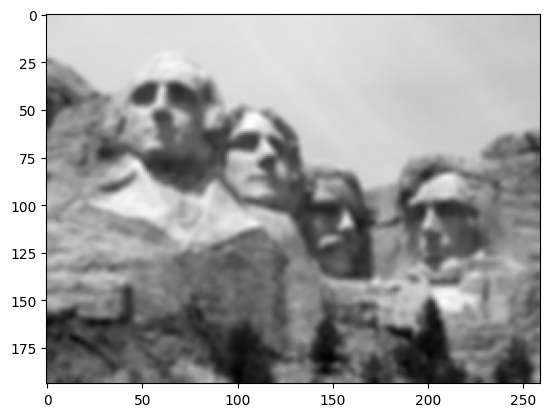

In [2]:
# 예시: img1 → img2 매칭

img1 = load_image_gray("img1.jpg")  # 이미지 경로 수정 필요
img1 = cv2.resize(img1, (0, 0), fx=0.1, fy=0.1) # 이미지 크기가 너무 클 경우 resize 하면 빠르게 동작 가능, 적당히 선택할 것
img1 = cv2.GaussianBlur(img1, (5, 5), 1.5) #높은 정확도를 위해 가우시안 블러 적용, 이렇게 하면 확실한 특징점 추출 가능능
Ix, Iy = compute_gradients(img1)
R = harris_response(Ix, Iy)
keypoints1 = np.argwhere(R > 0.1) #non-maximum suppression을 사용하지 않을 때 단순 thresholding으로 keypoint를 고르는 부분
# non-maximum suppression을 사용 시 추가 코드 필요
threshold_ratio = 0.005
keypoints1 = np.array(non_max_suppression(R, threshold_ratio))
# 이미지 시각화
plt.imshow(img1, cmap='gray')
plt.show()


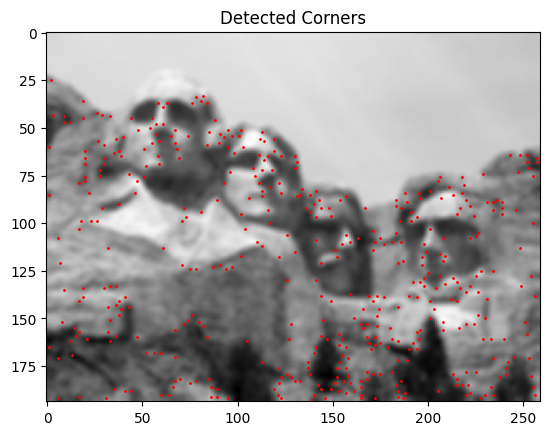

In [3]:
# 이미지 + feature 시각화
plt.imshow(img1, cmap='gray')
plt.scatter(keypoints1[:, 1], keypoints1[:, 0], c='r', s=1)
plt.title("Detected Corners")
plt.show()

In [ ]:
import numpy as np
import cv2

def compute_magnitude_orientation(Ix, Iy):
    """Gradient magnitude & orientation"""
  #구현 필요, magnitude의 x 방향 성분과 y 방향 성분을 보고 방향을 계산
    # gradient 크기 계산
    mag = np.sqrt(Ix**2 + Iy**2)
    #방향 계산, 범위를 0~360으로 맞춤, degree로 단위 변환환
    ori = (np.degrees(np.arctan2(Iy, Ix)) + 360) % 360
    return mag, ori

def compute_dominant_orientation(Ix, Iy, y, x, radius=8, num_bins=36):
    """keypoint 주변에서 dominant orientation 계산"""
  #구현 필요, x,y 위치 근처의 패치들의 orientation을 투표해서 dominant orientation 계산, 반환
  # patch size는 radius, 투표할 각(angle)의 단위는 360/num_bins가 될 것임
    
    #전체 이미지에 대한 gradient 크기 및 방향 계산
    mag, ori = compute_magnitude_orientation(Ix, Iy)
    h, w = mag.shape
    bin_width = 360 / num_bins #bin 너비 구함
    hist = np.zeros(num_bins, dtype=np.float32) #histogram 생성

    #반경 안의 모든 픽셀 보기
    for dy in range(-radius, radius + 1):
        yy = y + dy
        if yy < 0 or yy >= h: #이미지 경계 밖이면 무시
            continue
        for dx in range(-radius, radius + 1):
            xx = x + dx
            if xx < 0 or xx >= w: #이미지 경계 밖
                continue
            if dx*dx + dy*dy > radius*radius: #원형 부분 안의 픽셀만 고려함
                continue

            #조건에 맞는 픽셀이면 이 픽셀의 gradient 크기랑 방향 계산
            m = mag[yy, xx]
            angle = ori[yy, xx]
            bin_idx = int(angle // bin_width) % num_bins #인덱스로 변환하는 과정정
            hist[bin_idx] += m #magnitude를 빈에 넣음, 투표하기 위함임임

    max_bin = np.argmax(hist) #히스토그램에서 가장 값이 큰 빈 찾기, 투표함
    return (max_bin + 0.5) * bin_width #가장 큰 빈의 중앙 각도를 반환

######Q1+
def multi_scale(img,scales=[1.0, 0.75, 0.5, 0.25], k=0.04, window_size=3, threshold_ratio=0.005):
    #여러 해상도에서 harris 코너 검출
    keypoints = []
    h0, w0 = img.shape
    for s in scales: #스케일 비율만큼 이미지 리사이즈즈
        img_s = cv2.resize(img, (0,0), fx=s, fy=s, interpolation=cv2.INTER_LINEAR)
        Ix_s, Iy_s = compute_gradients(img_s) #리사이즈 된 이미지에서 gradient 계산산
        R_s = harris_response(Ix_s, Iy_s, k=k, window_size=window_size) #harris 코너 계산산
        kps_s = non_max_suppression(R_s, threshold_ratio)
        for y_s, x_s in kps_s: #리사이즈된 좌표에서 원본 이미지 좌표로 환산함함
            y0 = int(round(y_s / s))
            x0 = int(round(x_s / s))
            if 0 <= y0 < h0 and 0 <= x0 < w0:
                keypoints.append((y0, x0, s))
    # 중복 제거
    return list(set(keypoints))

######Q2+
def sift_descriptor(img, keypoints, patch_size=16, cell_size=4, num_bins=8):
    sigma1 = 1.5
    scale_data = {}
    #이미지 리사이즈 하고 gradient 계산하는 부분분
    for _, _, s in keypoints:
        if s not in scale_data:
            img_s = cv2.resize(img, (0,0), fx=s, fy=s, interpolation=cv2.INTER_LINEAR)
            
            sigma = sigma1 * s
            img_s = cv2.GaussianBlur(img_s, (5,5), sigma)
            
            Ix_s, Iy_s = compute_gradients(img_s)
            mag_s, ori_s = compute_magnitude_orientation(Ix_s, Iy_s)
            scale_data[s] = (img_s, Ix_s, Iy_s, mag_s, ori_s)

    descriptors = []
    cell_num = patch_size // cell_size #패치 내 한 변당 셀 개수
    half = patch_size // 2 #패치 중심에서 반경 구할때 쓰임
    ang = 360 / num_bins #히스토그램 한 빈의 각도 폭

    for y0, x0, s in keypoints:
        img_s, Ix_s, Iy_s, mag_s, ori_s = scale_data[s]
        y_s = int(round(y0 * s))
        x_s = int(round(x0 * s))
        dom = compute_dominant_orientation(Ix_s, Iy_s, y_s, x_s)

        histogram = np.zeros((cell_num, cell_num, num_bins), dtype=np.float32)
        for i in range(cell_num):
            for j in range(cell_num):
                y_start = y_s - half + i*cell_size
                x_start = x_s - half + j*cell_size
                for ii in range(cell_size):
                    for jj in range(cell_size):
                        yy = y_start + ii
                        xx = x_start + jj
                        #이미지 밖일 경우 무시
                        if yy<0 or yy>=img_s.shape[0] or xx<0 or xx>=img_s.shape[1]:
                            continue
                        a = (ori_s[yy,xx] - dom + 360) % 360
                        b = int(a // ang) % num_bins
                        histogram[i,j,b] += mag_s[yy,xx]

        #3D 히스토그램을 1D 벡터로 펼쳐서
        desc = histogram.flatten()
        #정규화 시킴, 벡터 길이가 1이 되도록
        norm = np.linalg.norm(desc)
        if norm > 0:
            desc = desc / norm
        #값이 너무 크면 잘라서 과도한 응답 억제. descriptor를 독점하지 않도록 해서 다양한 방향 특성을 반영하고 노이즈에 강하게 매칭하도록 함
        desc = np.clip(desc, None, 0.2)
        #다시 정규화
        norm = np.linalg.norm(desc)
        if norm > 0:
            desc = desc / norm

        descriptors.append(desc) #이 키포인트의 디스크립터를 리스트에 추가

    return np.array(descriptors) #결과 리스트를 NumPy 2D 배열로 변환해 반환
    #return # descriptors 반환


In [5]:
import numpy as np

def match_descriptors_nn(desc1, desc2):
    """
    Nearest Neighbor matching (brute-force L2 distance)
    desc1: (N1, D), desc2: (N2, D)
    return: list of (idx1, idx2)
    """
    matches = []
    for i, d1 in enumerate(desc1):
        dists = np.linalg.norm(desc2 - d1, axis=1)
        j = np.argmin(dists)
        matches.append((i, j))
    return matches

def match_descriptors_ratio_test(desc1, desc2, ratio_threshold):
  # NNDR(Nearest Neighbor Distance Ratio) 구현 필요
    matches = []
    for i, d1 in enumerate(desc1):
        # 모든 디스크립터와의 L2 거리 계산
        dists = np.linalg.norm(desc2 - d1, axis=1)
        if dists.size < 2:
            continue
        # 가장 가까운 두 이웃의 인덱스 추출
        idx_sorted = np.argsort(dists)
        best, second = idx_sorted[0], idx_sorted[1]
        # ratio 검사
        if dists[best] / dists[second] < ratio_threshold:
            matches.append((i, best))
    return matches

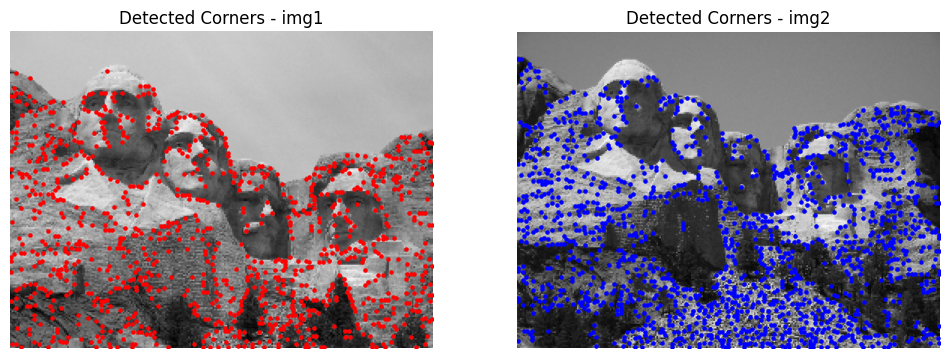

In [6]:
# 예시: img1 → img2 매칭

img1 = load_image_gray("img1.jpg")  # 이미지 경로 수정
img1 = cv2.resize(img1, (0, 0), fx=0.1, fy=0.1) # 이미지 크기가 너무 클 경우 resize 하면 빠르게 동작 가능, 적당히 선택할 것
Ix, Iy = compute_gradients(img1)
R = harris_response(Ix, Iy)
keypoints1 = np.array(non_max_suppression(R, threshold_ratio)) #리턴값이 코너점들이라 np.array 써야함


img2 = load_image_gray("img2.jpg")  # 이미지 경로 수정
img2 = cv2.resize(img2, (0, 0), fx=0.1, fy=0.1) # 이미지 크기가 너무 클 경우 resize 하면 빠르게 동작 가능, 적당히 선택할 것
Ix, Iy = compute_gradients(img2)
R = harris_response(Ix, Iy)
keypoints2 = np.array(non_max_suppression(R, threshold_ratio))

# keypoint 시각화 - img1
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img1, cmap='gray')
plt.scatter(keypoints1[:, 1], keypoints1[:, 0], c='r', s=5)
plt.title("Detected Corners - img1")
plt.axis('off')

# keypoint 시각화 - img2
plt.subplot(1, 2, 2)
plt.imshow(img2, cmap='gray')
plt.scatter(keypoints2[:, 1], keypoints2[:, 0], c='b', s=5)
plt.title("Detected Corners - img2")
plt.axis('off')

plt.show()


In [ ]:
scales = [1.0, 0.75, 0.5, 0.25]
threshold_ratio = 0.005
ratio_threshold = 0.92

kps1 = multi_scale(img1, scales=scales, threshold_ratio=threshold_ratio)
kps2 = multi_scale(img2, scales=scales, threshold_ratio=threshold_ratio)

desc1 = sift_descriptor(img1, kps1)
desc2 = sift_descriptor(img2, kps2)

In [8]:
# 이미지 매칭 부분
# 꼭 아래의 매칭만을 쓸 필요 없이, 여러 매칭을 조합하거나, 새로운 매칭을 제안해도 무방함
nn_matches = match_descriptors_nn(desc1, desc2)
ratio_matches = match_descriptors_ratio_test(desc1, desc2, ratio_threshold=0.92)

print(f"NN Matching: 총 {len(nn_matches)}개 매치")
print(f"Ratio Test Matching: 총 {len(ratio_matches)}개 매치")


NN Matching: 총 1965개 매치
Ratio Test Matching: 총 568개 매치


In [9]:
import matplotlib.pyplot as plt

def draw_matches(img1, img2, keypoints1, keypoints2, matches, max_display=50):
    """
    두 이미지 사이의 매칭 시각화
    """
    # 두 이미지 나란히 붙이기
    h1, w1 = img1.shape
    h2, w2 = img2.shape
    canvas = np.zeros((max(h1, h2), w1 + w2), dtype=np.uint8)
    canvas[:h1, :w1] = img1
    canvas[:h2, w1:] = img2

    # 매칭 점들 표시
    plt.figure(figsize=(12, 6))
    plt.imshow(canvas, cmap='gray')
    plt.axis('off')

    shown = 0
    for idx1, idx2 in matches:
        if shown >= max_display:
            break
        y1, x1 = keypoints1[idx1]
        y2, x2 = keypoints2[idx2]
        plt.plot([x1, x2 + w1], [y1, y2], 'r', linewidth=0.8)
        plt.scatter([x1, x2 + w1], [y1, y2], c='yellow', s=10)
        shown += 1

    plt.title(f"Matching Keypoints (showing up to {max_display})")
    plt.show()


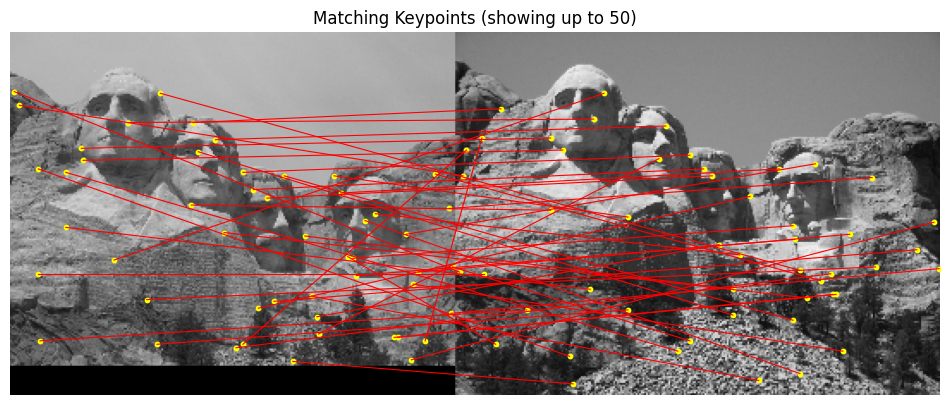

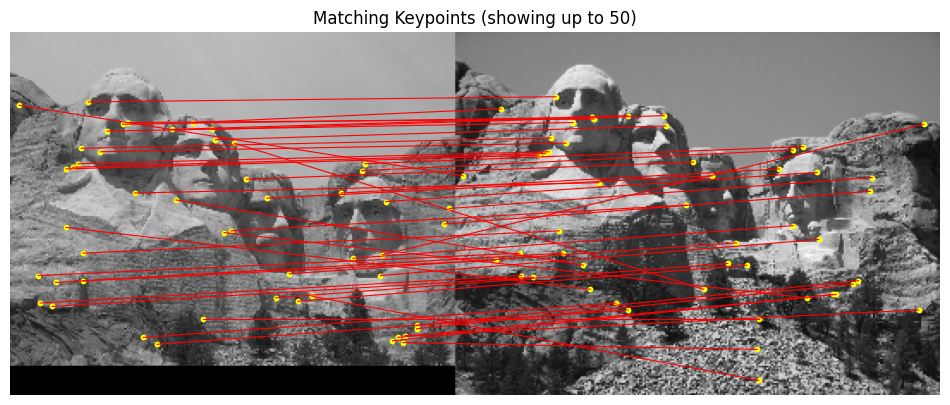

In [10]:
pts1_2d = [(r, c) for (r, c, s) in kps1]
pts2_2d = [(r, c) for (r, c, s) in kps2]

# 이제 draw_matches 호출
draw_matches(img1, img2, pts1_2d, pts2_2d, nn_matches)
draw_matches(img1, img2, pts1_2d, pts2_2d, ratio_matches)

In [11]:
def compute_homography(src_pts, dst_pts):
    """
    최소 4개 이상의 점쌍으로부터 H 추정 (DLT 방식)
    src_pts, dst_pts: (N, 2) numpy arrays
    """
    N = src_pts.shape[0]
    A = []

    for i in range(N):
        x, y = src_pts[i]
        x_, y_ = dst_pts[i]

        A.append([-x, -y, -1,  0,  0,  0, x * x_, y * x_, x_])
        A.append([ 0,  0,  0, -x, -y, -1, x * y_, y * y_, y_])

    A = np.array(A)
    _, _, V = np.linalg.svd(A)
    H = V[-1].reshape(3, 3) # SVD 후 가장 작은 eigenvalue에 해당하는 eigenvector를 solution으로 사용
    return H / H[2, 2]  # 정규화


In [12]:
def ransac_homography(src_pts, dst_pts, num_iter=20000, thresh=1.5):
    """
    RANSAC으로 H 추정 및 inlier 추출
    """
    best_H = None
    best_inliers = []

    N = len(src_pts)

    for _ in range(num_iter):
        idx = np.random.choice(N, 4, replace=False)
        H = compute_homography(src_pts[idx], dst_pts[idx])

        # 변환 후 거리 계산
        src_h = np.hstack([src_pts, np.ones((N, 1))])
        projected = (H @ src_h.T).T
        projected /= projected[:, 2][:, None]
        dst_projected = projected[:, :2]

        dists = np.linalg.norm(dst_pts - dst_projected, axis=1)
        inliers = np.where(dists < thresh)[0]

        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_H = H

    return best_H, best_inliers


In [ ]:
# 매칭 결과에서 좌표 추출
'''
src_pts = np.array([keypoints1[i] for i, _ in ratio_matches])
dst_pts = np.array([keypoints2[j] for _, j in ratio_matches])
'''

src_pts = np.array([(kps1[i][1], kps1[i][0]) for i, _ in ratio_matches], dtype=np.float32)
dst_pts = np.array([(kps2[j][1], kps2[j][0]) for _, j in ratio_matches], dtype=np.float32)

# RANSAC 수행
H, inliers = ransac_homography(src_pts, dst_pts)

# Inlier 개수 출력
print("Inliers:", len(inliers), "/", len(ratio_matches))


Inliers: 260 / 568


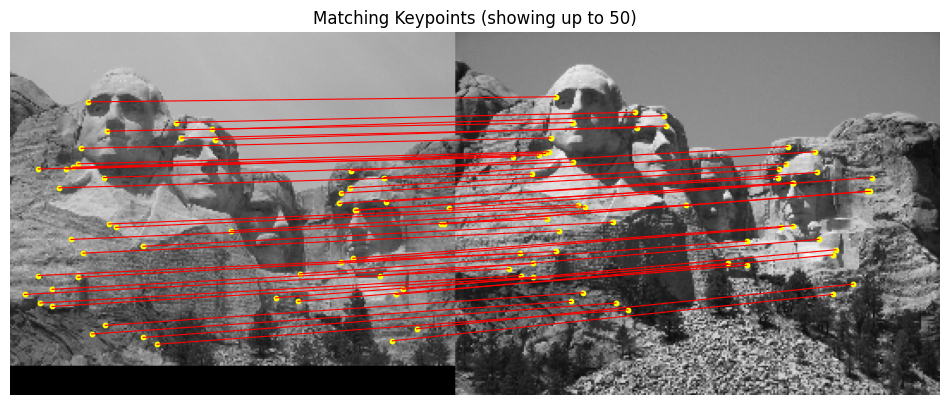

In [14]:
# inlier 그려보기

inlier_matches = [ratio_matches[i] for i in inliers]
# draw_matches(img1.astype(np.uint8), img2.astype(np.uint8), keypoints1, keypoints2, inlier_matches)
draw_matches(img1.astype(np.uint8), img2.astype(np.uint8), pts1_2d, pts2_2d, inlier_matches)

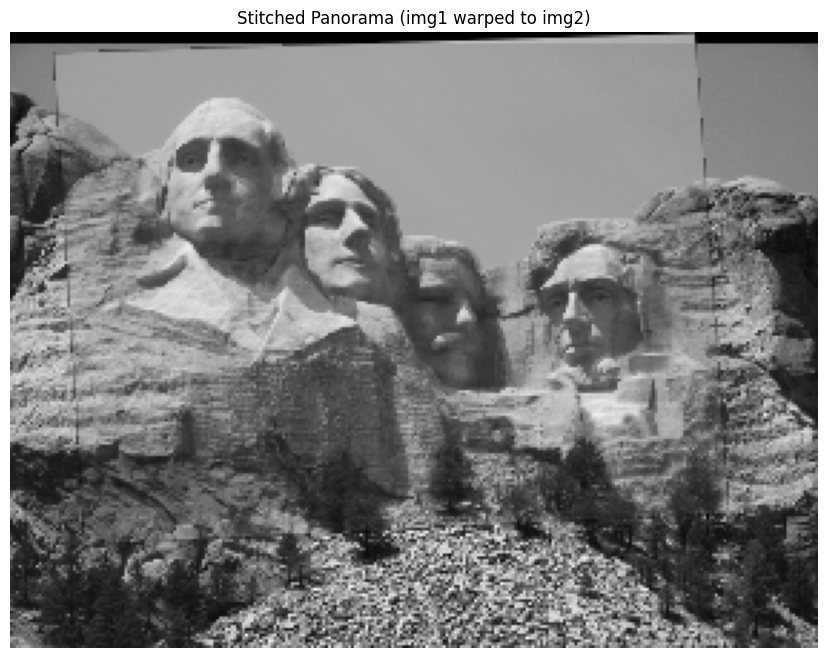

In [15]:
def warp_image(img_src, H, output_shape, offset=(0, 0)):
    """
    Homography H를 적용하여 img_src를 새로운 시점으로 warp
    """
    h, w = output_shape
    offset_x, offset_y = offset
    translation = np.array([[1, 0, offset_x],
                            [0, 1, offset_y],
                            [0, 0, 1]])
    H_offset = translation @ H
    warped = cv2.warpPerspective(img_src, H_offset, (w, h))
    return warped


def stitch_images(img1, img2, H):
    """
    이미지 2장을 하나의 파노라마로 스티칭
    img2: 기준 이미지 (reference)
    img1: 변환 이미지 (warp 대상)
    H: img1 → img2로 변환되는 Homography
    """
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    # img1의 코너들을 img2 좌표계로 변환
    corners_img1 = np.array([[0, 0], [0, h1], [w1, h1], [w1, 0]], dtype=np.float32)
    corners_img1 = np.hstack([corners_img1, np.ones((4, 1))])
    transformed_corners = (H @ corners_img1.T).T
    transformed_corners /= transformed_corners[:, 2][:, None]
    corners = transformed_corners[:, :2]

    # 전체 캔버스 크기 계산
    all_x = np.hstack([corners[:, 0], [0, w2]])
    all_y = np.hstack([corners[:, 1], [0, h2]])
    min_x, max_x = int(np.floor(all_x.min())), int(np.ceil(all_x.max()))
    min_y, max_y = int(np.floor(all_y.min())), int(np.ceil(all_y.max()))

    output_w = max_x - min_x
    output_h = max_y - min_y
    offset = (-min_x, -min_y)

    # img1을 warp해서 img2 좌표계에 맞추기
    warped_img1 = warp_image(img1, H, (output_h, output_w), offset)

    # img2를 정위치에 넣기
    stitched = np.zeros_like(warped_img1)
    stitched[offset[1]:offset[1]+h2, offset[0]:offset[0]+w2] = img2

    # blending
    mask = (warped_img1 > 0) & (stitched > 0)
    stitched[mask] = (stitched[mask] / 2 + warped_img1[mask] / 2).astype(np.uint8)
    stitched[~mask] += warped_img1[~mask]

    return stitched

# img1 → img2 방향 H로 img1을 warp
stitched = stitch_images(img1.astype(np.uint8), img2.astype(np.uint8), H)

plt.figure(figsize=(12, 8))
plt.imshow(stitched, cmap='gray')
plt.title("Stitched Panorama (img1 warped to img2)")
plt.axis('off')
plt.show()
